In [84]:
import numpy as np
import pandas as pd
import random
import os

# tf
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, array_to_img, img_to_array

# shap
import shap

# pltos and images
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image

# silence TF
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

random.seed(2)

In [85]:
BASE = 'Brain_Tumor'
IMG_SIZE = (224, 224)

# load image from folder
def load_split(split):
    split_dir = os.path.join(BASE, split)
    # read class from folder name
    classes = sorted(c for c in os.listdir(split_dir)
                     if os.path.isdir(os.path.join(split_dir, c)))
    cls_to_idx = {c: i for i, c in enumerate(classes)}

    X, y = [], []
    # read images from each folder, transform classes to interger
    for cls in classes:
        cls_dir = os.path.join(split_dir, cls)
        for fname in os.listdir(cls_dir):
            fpath = os.path.join(cls_dir, fname)
            img = load_img(fpath, target_size=IMG_SIZE)
            X.append(img_to_array(img))      # (224,224,3) float32
            y.append(cls_to_idx[cls])        # label from folder name
    
    # shuffle the data
    X = np.array(X)
    y = np.array(y)

    idx = np.random.permutation(np.arange(len(X)))
    X = X[idx]
    y = y[idx]
    
    return np.array(X), np.array(y), classes

X_train, y_train, classes = load_split('train')
X_test,  y_test,  _       = load_split('test')

print(X_train.shape, y_train.shape)   # e.g. (5712, 224, 224, 3) (5712,)
print(X_test.shape,  y_test.shape)    # e.g. (1311, 224, 224, 3) (1311,)
print(classes)                        # ['glioma','meningioma','notumor','pituitary']

(5723, 224, 224, 3) (5723,)
(1430, 224, 224, 3) (1430,)
['glioma', 'meningioma', 'notumor', 'pituitary']


### Review few images

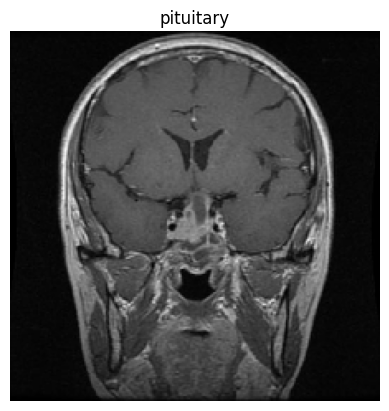

In [86]:
import matplotlib.pyplot as plt
plt.imshow(array_to_img(X_train[0]))
plt.title(classes[y_train[0]])     # show its class name
plt.axis("off")
plt.show()

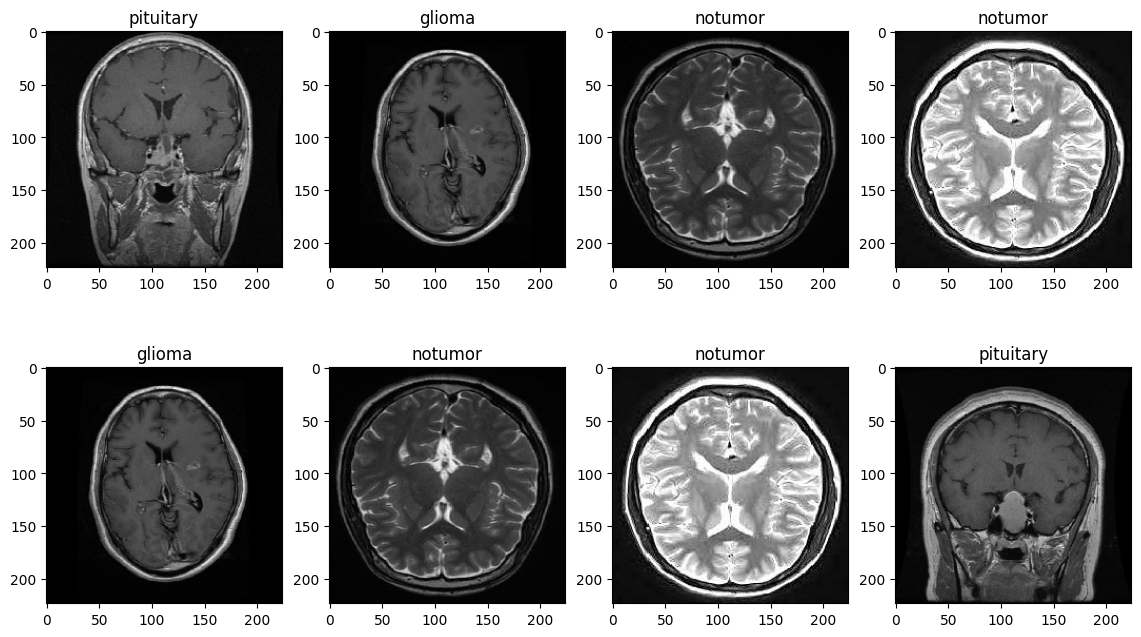

In [87]:
nrows, ncols = 2, 4
f, axs = plt.subplots(nrows, ncols, figsize=(14,8))

for i in range(nrows):
    for j in range(ncols):
        axs[i,j].imshow(array_to_img(X_train[i+j]))
        axs[i,j].set_title(classes[y_train[i+j]])

### Augment images

`Checking classes`

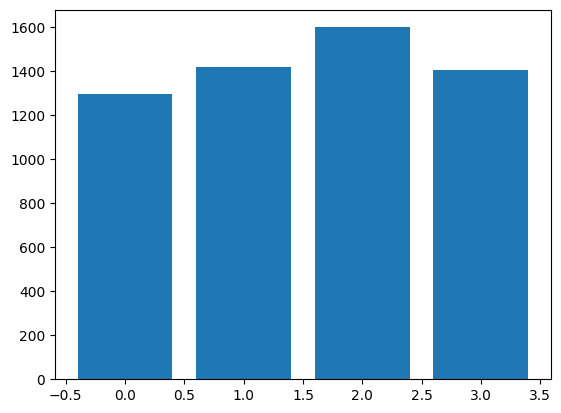

In [88]:
classes_count = pd.DataFrame(y_train).value_counts()

idx = [x[0] for x in classes_count.index.tolist()]

plt.bar(idx, classes_count.values);

In [89]:
Img_size = (244,244)
Delta = 0.3
Contrast_f = 3

X_train = tf.image.resize(X_train, Img_size)
X_test = tf.image.resize(X_test, Img_size)

# scale pixel between 0 - 1
X_train = tf.image.rgb_to_grayscale(X_train) / 255.0
X_test = tf.image.rgb_to_grayscale(X_test) / 255.0

# adjust brightness
X_train_augm = tf.image.adjust_brightness(X_train, delta=Delta)


# adjust contrast
X_train_augm = tf.image.adjust_contrast(X_train_augm, contrast_factor=Contrast_f)


# flip
X_train_augm = tf.image.flip_left_right(X_train_augm)


# combine the augm with original
X_train = tf.concat([X_train, X_train_augm], axis=0)
y_train = tf.concat([y_train, y_train], axis=0)


shuffle = np.random.permutation(np.arange(len(X_train)))
X_train = tf.gather(X_train, shuffle)
y_train = tf.gather(y_train, shuffle)

### Model

`Build the model`

In [99]:
tf.keras.backend.clear_session()
tf.random.set_seed(1234)

input1 = tf.keras.layers.Input(shape=(224,224), name='input1')

input2 = tf.keras.layers.Flatten(name='Flatten')(input1)

input3 = tf.keras.layers.Dense(units=12*32*32, activation='relu', name='fc_1')(input2)

input4 = tf.keras.layers.Dense(units=6*32*32, activation='relu', name='fc_2')(input3)

input5 = tf.keras.layers.Dense(units=2*32*32, activation='relu', name='fc_3')(input4)

input6 = tf.keras.layers.Dropout(rate=0.3, name='Dropout')(input5)

out = tf.keras.layers.Dense(units=4, activation=None, name='Out')(input6)

# initialize the model
model = tf.keras.models.Model(inputs=input1, outputs=out)


`Compile`

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
)